# Taller de Feature Engineering: Seleccion y creacion de variables

**Bootcamp:** Python - PY4
**Modulo:** Machine Learning Avanzado y Feature Engineering

## De donde venimos

- **Sesion 1**: entrenamos un Linear Regression baseline, sin feature engineering. RMSE ~136.31, R2 ~0.405.
- **Sesion 2**: construimos 3 tecnicas de feature engineering (Winsorization, Target Encoding, variables ciclicas) y demostramos su impacto. La mejora fue grande (RMSE de 136.31 a 99.97, R2 de 0.405 a 0.679). Tambien vimos que el log-transform no siempre ayuda al RMSE.

## De que trata esta sesion

1. Vamos a entrenar un Random Forest Regressor model, que tiene más parámetros para ajustar en comparación con la Linear Regression.
2. Vamos a comparar brevemente Random Search contra Optuna (optimizacion Bayesiana), para entender por que Optuna es hoy el estandar.
3. Vamos a usar **Optuna** para encontrar los mejores hiperparametros del Random Forest, y vamos a graficar la importancia de cada hiperparametro (`plot_param_importances`).
4. Opcionalmente, vamos a probar **PyCaret** y su funcion `compare_models()`.
5. Vamos a armar la tabla comparativa final: **Modelo Inicial vs. Modelo Optimizado**, y vamos a escribir una conclusion sobre que tecnica tuvo mayor impacto en todo el taller.


## Paso 1: Configuracion y reconstruccion rapida del trabajo previo

Empezamos igual que siempre: importamos librerias y recargamos el dataset. En esta sesion vamos a necesitar ademas `optuna` para la optimizacion Bayesiana.


In [ ]:
!pip install optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 24.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
sns.set_style("whitegrid")

URL = "https://raw.githubusercontent.com/Camille-Le-Roy/data_analytics_resources/main/Module_02_machine_learning_and_feature_engineering/datasets/bikeshare_Washington.csv"
df = pd.read_csv(URL)
df.head()


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Volvemos a separar entrenamiento y prueba con el mismo `random_state` que en las sesiones anteriores, para que todo siga siendo comparable.


In [ ]:
features_base = ["season", "yr", "mnth", "hr", "holiday", "weekday",
                  "workingday", "weathersit", "temp", "atemp", "hum", "windspeed"]

X = df[features_base].copy()
y = df["cnt"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Entrenamiento:", X_train.shape, " Prueba:", X_test.shape)


Entrenamiento: (14016, 12)  Prueba: (3504, 12)


### Construimos un modelo inicial : Random Forest Regressor

Antes de optimizar nada, necesitamos tener a mano el modelo que vamos a usar como punto de comparacion: el Random Forest.


In [ ]:
# Crea un modelo Random Forest con 100 árboles
rf_inicial = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_inicial.fit(X_train, y_train) # Entrena el modelo con los datos de entrenamiento

y_pred_inicial = rf_inicial.predict(X_test) # Genera las predicciones sobre el conjunto de prueba

# Calcula las métricas de desempeño
rmse_inicial = np.sqrt(mean_squared_error(y_test, y_pred_inicial))
r2_inicial = r2_score(y_test, y_pred_inicial)

print(f"Modelo inicial - RMSE: {rmse_inicial:.2f}")
print(f"Modelo inicial - R2: {r2_inicial:.4f}")

Modelo inicial - RMSE: 41.46
Modelo inicial - R2: 0.9450


### Reconstruyendo las features de la sesion 2

Ahora recreamos rapidamente el mismo pipeline de feature engineering que armamos en la sesion 2: Winsorization sobre `windspeed` y `hum`, Target Encoding sobre `hr`, y variables ciclicas sobre `hr` y `mnth`. Como ya explicamos el detalle de cada tecnica en la sesion anterior, aca simplemente las reconstruimos para poder usarlas con el Random Forest.


In [ ]:
def calcular_limites(serie, percentil_bajo=5, percentil_alto=95):
    limite_bajo = np.percentile(serie, percentil_bajo)
    limite_alto = np.percentile(serie, percentil_alto)
    return limite_bajo, limite_alto

def aplicar_winsorization(X, columna, limites):
    limite_bajo, limite_alto = limites
    es_outlier = ((X[columna] < limite_bajo) | (X[columna] > limite_alto)).astype(int)
    valor_winsorizado = X[columna].clip(lower=limite_bajo, upper=limite_alto)
    return valor_winsorizado, es_outlier

def transformar_ciclica(valor, periodo):
    seno = np.sin(2 * np.pi * valor / periodo)
    coseno = np.cos(2 * np.pi * valor / periodo)
    return seno, coseno

# Winsorization
limites_windspeed = calcular_limites(X_train["windspeed"])
limites_hum = calcular_limites(X_train["hum"])

X_train["windspeed_wins"], X_train["windspeed_outlier"] = aplicar_winsorization(X_train, "windspeed", limites_windspeed)
X_test["windspeed_wins"], X_test["windspeed_outlier"] = aplicar_winsorization(X_test, "windspeed", limites_windspeed)

X_train["hum_wins"], X_train["hum_outlier"] = aplicar_winsorization(X_train, "hum", limites_hum)
X_test["hum_wins"], X_test["hum_outlier"] = aplicar_winsorization(X_test, "hum", limites_hum)

# Target Encoding
media_por_hora = y_train.groupby(X_train["hr"]).mean()
media_global = y_train.mean()

X_train["hr_target_enc"] = X_train["hr"].map(media_por_hora).fillna(media_global)
X_test["hr_target_enc"] = X_test["hr"].map(media_por_hora).fillna(media_global)

# Variables ciclicas
X_train["hr_sin"], X_train["hr_cos"] = transformar_ciclica(X_train["hr"], 24)
X_test["hr_sin"], X_test["hr_cos"] = transformar_ciclica(X_test["hr"], 24)

X_train["mnth_sin"], X_train["mnth_cos"] = transformar_ciclica(X_train["mnth"] - 1, 12)
X_test["mnth_sin"], X_test["mnth_cos"] = transformar_ciclica(X_test["mnth"] - 1, 12)

features_finales = [
    "season", "yr", "holiday", "weekday", "workingday", "weathersit",
    "temp", "atemp",
    "windspeed_wins", "windspeed_outlier",
    "hum_wins", "hum_outlier",
    "hr_target_enc",
    "hr_sin", "hr_cos",
    "mnth_sin", "mnth_cos"
]

X_train_fe = X_train[features_finales]
X_test_fe = X_test[features_finales]

X_train_fe.head()


,season,yr,holiday,weekday,workingday,weathersit,temp,atemp,windspeed_wins,windspeed_outlier,hum_wins,hum_outlier,hr_target_enc,hr_sin,hr_cos,mnth_sin,mnth_cos
17440,1,1,0,5,1,1,0.30,0.3030,0.1343,0,0.49,0,312.100520,-0.866025,-0.500000,-0.500000,0.866025
16867,4,1,0,2,1,1,0.48,0.4697,0.2239,0,0.67,0,309.410562,-0.965926,0.258819,-0.500000,0.866025
14851,3,1,0,1,1,1,0.62,0.6212,0.2985,0,0.38,0,309.410562,-0.965926,0.258819,-0.866025,-0.500000
5446,3,0,0,1,1,1,0.66,0.6212,0.2537,0,0.69,0,130.043706,-0.500000,0.866025,-0.500000,-0.866025
6025,3,0,0,5,1,2,0.62,0.5152,0.1642,0,0.93,1,32.613636,0.258819,0.965926,-0.866025,-0.500000


## Paso 2: Estrategias de busqueda de hiperparametros

Antes de optimizar, recordemos las 3 estrategias principales para buscar hiperparametros (las vimos en la teoria de esta semana):

- **Grid Search**: prueba todas las combinaciones posibles de una grilla fija. Es exhaustivo, pero muy lento cuando hay varios hiperparametros continuos (la grilla crece exponencialmente).
- **Random Search**: prueba combinaciones al azar dentro de los rangos definidos. Suele encontrar mejores resultados que Grid Search en el mismo tiempo, porque no se limita a puntos fijos de una grilla.
- **Optimizacion Bayesiana (Optuna)**: usa los resultados de los intentos anteriores para decidir que combinacion probar a continuacion (algoritmo TPE, "Tree-structured Parzen Estimator"). Es mas eficiente que Random Search porque no busca "a ciegas": aprende de la historia de intentos.

Con hiperparametros continuos como los de un Random Forest (`max_features`, por ejemplo), Grid Search se vuelve poco practico. Por eso, vamos a comparar directamente **Random Search** contra **Optuna**, usando el mismo numero de intentos y el mismo espacio de busqueda, para ver la diferencia en la practica.

Para evaluar cada combinacion de hiperparametros, vamos a usar validacion cruzada (`cross_val_score` con `cv=3`) sobre el train set, en vez de mirar directamente el test set. Esto evita que "espiemos" el test set durante la busqueda de hiperparametros.


**Espacio de búsqueda de hiperparámetros**

- **`n_estimators`**: número de árboles del bosque. Más árboles suelen mejorar la estabilidad del modelo, a costa de un mayor tiempo de entrenamiento.

- **`max_depth`**: profundidad máxima de cada árbol. Valores pequeños reducen el riesgo de sobreajuste, mientras que valores grandes permiten capturar relaciones más complejas.

- **`min_samples_split`**: número mínimo de observaciones necesarias para dividir un nodo interno. Valores mayores generan árboles más simples.

- **`min_samples_leaf`**: número mínimo de observaciones que debe contener una hoja. Ayuda a evitar hojas con muy pocos ejemplos y reduce el sobreajuste.

- **`max_features`**: proporción de variables consideradas en cada división del árbol. Valores menores aumentan la diversidad entre los árboles del bosque.

In [ ]:
# Define el espacio de búsqueda de hiperparámetros
param_dist = {
    "n_estimators": np.arange(50, 300),
    "max_depth": np.arange(3, 20),
    "min_samples_split": np.arange(2, 20),
    "min_samples_leaf": np.arange(1, 10),
    "max_features": np.linspace(0.3, 1.0, 20),
}


>**¿Cómo definir el espacio de búsqueda?**
>
>No existe una fórmula para elegir el espacio de búsqueda de los >hiperparámetros. Normalmente se define combinando:
>
>- El conocimiento sobre qué hace cada hiperparámetro.
>- Rangos recomendados en la documentación o en la práctica.
>- El tamaño y la complejidad del dataset.
>- El tiempo de cómputo disponible.
>
>En la práctica, suele hacerse una primera búsqueda amplia y, a partir de los >mejores resultados obtenidos, refinar el rango en una segunda búsqueda.

In [ ]:
# Crea el modelo base de Random Forest
rf_random_search = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)

# Configura la búsqueda aleatoria de hiperparámetros
random_search = RandomizedSearchCV(
    rf_random_search,
    param_distributions=param_dist,          # Espacio de búsqueda
    n_iter=20,                               # Prueba 20 combinaciones aleatorias
    cv=3,                                    # Utiliza validación cruzada de 3 folds
    scoring="neg_root_mean_squared_error",   # Optimiza el RMSE
    random_state=RANDOM_STATE,
    n_jobs=1
)

# Ejecuta la búsqueda sobre el conjunto de entrenamiento
random_search.fit(X_train_fe, y_train)

# Muestra el mejor resultado y la combinación de hiperparámetros encontrada
print("Mejor RMSE (validacion cruzada) con Random Search:", -random_search.best_score_)
print("Mejores parametros:", random_search.best_params_)

Mejor RMSE (validacion cruzada) con Random Search: 47.23335533067324
Mejores parametros: {'n_estimators': np.int64(232), 'min_samples_split': np.int64(12), 'min_samples_leaf': np.int64(2), 'max_features': np.float64(0.8526315789473684), 'max_depth': np.int64(14)}


> **¿Qué es la cross-validation (`cv=3`)?**   
>
> La validación cruzada ('cross validation') divide el train set en **3 partes (folds)**. En cada iteración, el modelo se entrena con 2 partes y se evalúa sobre la tercera. Este proceso se repite 3 veces, de modo que cada observación se utiliza una vez para validar y dos veces para entrenar. Finalmente, se promedia el desempeño obtenido en los 3 folds, proporcionando una estimación más robusta que una única división entrenamiento/prueba.  
```text
Fold 1: [ Validación ] [ Entrenamiento ] [ Entrenamiento ]

Fold 2: [ Entrenamiento ] [ Validación ] [ Entrenamiento ]

Fold 3: [ Entrenamiento ] [ Entrenamiento ] [ Validación ]
```

> si cv=5, el modelo se entrena 5 veces, utilizando 4 folds para entrenar y 1 para validar.

Guardemos este resultado para compararlo con Optuna en un momento.


In [ ]:
rmse_random_search = -random_search.best_score_

## Paso 3: Optimizacion con Optuna

Ahora hacemos lo mismo, pero con Optuna. La logica de Optuna es un poco distinta a la de scikit-learn: en vez de darle una grilla o una lista de distribuciones, le definimos una **funcion objetivo**. Esa funcion recibe un `trial` (un intento), y dentro de la funcion le pedimos al `trial` que sugiera un valor para cada hiperparametro, dentro del rango que nosotros definamos.

Usamos el mismo espacio de busqueda y el mismo esquema de validacion cruzada que usamos con Random Search, para que la comparacion sea justa.


In [ ]:
# Define la función objetivo que Optuna intentará minimizar. Cada prueba corresponde a una combinación diferente de hiperparámetros.
def objective(trial):

    # Optuna propone valores para cada hiperparámetro dentro del rango definido
    n_estimators = trial.suggest_int("n_estimators", 50, 300)          # --> "Optuna, elige un numero de arbol entre 50 y 300, pruébalo y descubre si mejora el modelo."
    max_depth = trial.suggest_int("max_depth", 3, 20)                  # --> "Optuna, elige un profundidad máxima de los árboles entre 3 y 20, pruébalo y descubre si mejora el modelo."
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)  # --> "Optuna, elige un Mínimo de muestras para dividir un nodo entre 2 y 20, pruébalo y descubre si mejora el modelo."
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)    # --> "Optuna, elige unMínimo de muestras en una hoja entre 1 y 10, pruébalo y descubre si mejora el modelo."
    max_features = trial.suggest_float("max_features", 0.3, 1.0)      # --> "Optuna, elige unProporción de variables consideradas en cada división entre 0.3 y 1.0, pruébalo y descubre si mejora el modelo."

    # Crea el modelo Random Forest con los hiperparámetros seleccionados por Optuna
    modelo = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    # Evalúa el modelo mediante validación cruzada y calcula el RMSE promedio
    # Se utiliza el signo negativo porque sklearn maximiza los scores por defecto. Queremos maximizar "-RMSE" porque queremons minimizar RMSE
    rmse_cv = -cross_val_score(
        modelo,
        X_train_fe,
        y_train,
        cv=3,
        scoring="neg_root_mean_squared_error",
        n_jobs=1
    ).mean()

    # Optuna intentará encontrar los hiperparámetros que minimicen este valor
    return rmse_cv

<function __main__.objective(trial)>

Creamos el estudio de Optuna con direccion `minimize` (queremos el RMSE mas bajo posible), y lo corremos por 20 intentos (`n_trials`), el mismo numero que usamos con Random Search.

Esto puede tardar un par de minutos en correr, ya que cada intento entrena varios Random Forest (uno por cada fold de la validacion cruzada).


In [ ]:
# Crea un "study" de Optuna, es decir. Un study es un proceso de optimización donde se probarán diferentes combinaciones de hiperparámetros.
# "minimize" indica que queremos encontrar el menor RMSE posible.
study = optuna.create_study(direction="minimize")

# Ejecuta la optimización: Optuna prueba 20 combinaciones diferentes de hiperparámetros utilizando la función objective definida anteriormente
study.optimize(objective, n_trials=20)


print("Mejor RMSE (validacion cruzada) con Optuna:", round(study.best_value,3))
print("Mejores parametros:", study.best_params)

Mejor RMSE (validacion cruzada) con Optuna: 47.197
Mejores parametros: {'n_estimators': 141, 'max_depth': 15, 'min_samples_split': 14, 'min_samples_leaf': 1, 'max_features': 0.6571387553549469}


Un study contiene toda la información del proceso:

-las diferentes pruebas realizadas (trials)  
-los hiperparámetros probados en cada prueba  
-el resultado obtenido (RMSE).  
-cuál fue la mejor combinación encontrada  

### Comparando Random Search vs Optuna

Veamos lado a lado el mejor RMSE de validacion cruzada que encontro cada estrategia, usando el mismo numero de intentos.

In [ ]:
comparacion_busqueda = pd.DataFrame([
    {c"Random Search", "rmse_cv": round(rmse_random_search,3)},
    {"estrategia": "Optuna (Bayesiano)", "rmse_cv": round(study.best_value,3)},
])

comparacion_busqueda


,estrategia,rmse_cv
0,Random Search,47.233
1,Optuna (Bayesiano),47.197


  
   
**¿Qué estrategia de búsqueda encontró la mejor combinación de hiperparámetros según el RMSE de validación cruzada?**   

Es esperable que Optuna encuentre un resultado igual o levemente mejor que Random Search, en un tiempo similar. La diferencia no siempre es enorme en un solo experimento (hay algo de variabilidad), pero la idea de fondo es la que importa: Optuna aprende de los intentos anteriores en vez de probar completamente al azar, y esa ventaja se vuelve mas clara cuantos mas hiperparametros y mas intentos tengamos.



### Grafico de importancia de hiperparametros

Optuna nos permite ver que hiperparametros tuvieron mas influencia sobre el resultado, usando `plot_param_importances`. Esto es util para entender donde conviene enfocar el esfuerzo si tuvieramos que seguir ajustando el modelo.

/tmp/ipython-input-13-2093320283.py:3: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


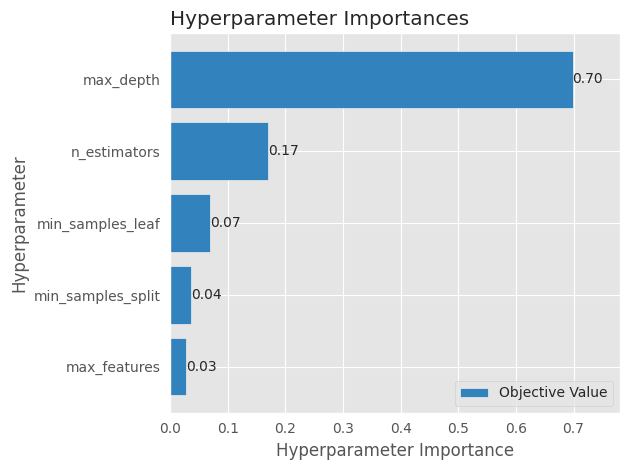

In [ ]:
from optuna.visualization.matplotlib import plot_param_importances

plot_param_importances(study)
plt.tight_layout()
plt.show()


### Entrenando el modelo optimizado

Con los mejores hiperparametros encontrados por Optuna, entrenamos el modelo final sobre todo el conjunto de entrenamiento, y lo evaluamos sobre el conjunto de prueba (el mismo que usamos para el modelo inicial de la sesion 1, asi la comparacion es directa).


In [ ]:
mejores_parametros = study.best_params # Recupera los mejores hiperparámetros encontrados por Optuna

# Crea un nuevo Random Forest utilizando la mejor combinación de parámetros
rf_optimizado = RandomForestRegressor(
    **mejores_parametros,      # Introduce automáticamente los hiperparámetros encontrados
    random_state=RANDOM_STATE, # Mantiene resultados reproducibles
    n_jobs=-1                  # Utiliza todos los núcleos disponibles
)

# Entrena el modelo final con los mejores parámetros sobre todos los datos de entrenamiento
rf_optimizado.fit(X_train_fe, y_train)

# Genera predicciones sobre el test set (datos nunca utilizados durante el entrenamiento)
y_pred_optimizado = rf_optimizado.predict(X_test_fe)

# Calcula las métricas finales de evaluación
rmse_optimizado = np.sqrt(mean_squared_error(y_test, y_pred_optimizado))
r2_optimizado = r2_score(y_test, y_pred_optimizado)

print(f"Modelo optimizado - RMSE: {rmse_optimizado:.2f}")
print(f"Modelo optimizado - R2: {r2_optimizado:.4f}")

Modelo optimizado - RMSE: 41.29
Modelo optimizado - R2: 0.9454


### Nota sobre el uso de `**`

En Python, el operador `**` permite **desempaquetar un diccionario** y utilizar sus elementos como argumentos del modelo.

Por ejemplo:

```python
rf_optimizado = RandomForestRegressor(
    **mejores_parametros,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
```

es exactamente equivalente a escribir manualmente:

```python
rf_optimizado = RandomForestRegressor(
    n_estimators=180,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features=0.7,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
```

La ventaja de usar `**mejores_parametros` es que Optuna devuelve automáticamente los mejores hiperparámetros en formato diccionario, evitando tener que copiarlos manualmente.

## Fase 4: Comparativa final

Llego el momento de armar la tabla que resume todo el taller: el **Modelo Inicial** (Linear Regression de la sesion 1, sin feature engineering ni tuning) contra el **Modelo Optimizado** (Random Forest con las features de la sesion 2, mas los hiperparametros encontrados por Optuna).


In [ ]:
tabla_comparativa_final = pd.DataFrame([
    {
        "Modelo": "Basic Random Forest",
        "RMSE": rmse_inicial,
        "R2": r2_inicial
    },
    {
        "Modelo": "Random Forest + FE + Optuna",
        "RMSE": rmse_optimizado,
        "R2": r2_optimizado
    },
])

tabla_comparativa_final


,Modelo,RMSE,R2
0,Basic Random Forest,41.456221,0.944959
1,Random Forest + FE + Optuna,41.287311,0.945407


### Conclusion

> A lo largo del taller, la tecnica que mas impacto tuvo no fue una sola, sino la combinacion de dos factores: el tipo de modelo y el tipo de mejora aplicada. Con Random Forest, tanto el feature engineering como el ajuste de hiperparametros con Optuna generaron mejoras reales pero moderadas en el RMSE, porque los arboles de decision ya son flexibles por naturaleza y no dependen tanto de la escala o forma de las variables. En cambio, al aplicar las mismas tecnicas de feature engineering sobre una Regresion Lineal, la mejora fue mucho mas grande, porque ese modelo si depende directamente de que las variables esten bien representadas.   
La leccion principal es que no existe una tecnica "ganadora" en abstracto: el impacto de cada mejora depende del modelo con el que se combine, y por eso conviene medir siempre en lugar de asumir.

### Cierre del taller

En estas 3 sesiones recorrimos el ciclo completo de un proyecto de Machine Learning aplicado:

1. Establecer un baseline solido antes de optimizar (sesion 1).
2. Aplicar tecnicas de feature engineering y medir su impacto real, no asumido (sesion 2).
3. Optimizar hiperparametros de forma sistematica con Optuna, y comparar contra alternativas como Random Search (sesion 3).
4. Documentar los resultados en una tabla comparativa y sacar conclusiones basadas en evidencia, no en intuicion.

Este mismo proceso es el que van a replicar en el ejercicio final, con su propio dataset asignado.
